# 2. Random Forest

Many decorrelated decision trees, averaged.

Each tree sees a bootstrap sample of the training days and a random subset of
features at every split, so the trees make different mistakes and averaging cancels
much of the noise. This buys two things linear regression cannot offer: it captures
thresholds (nothing much happens until it is hot *and* still) and it handles the
correlated temperature block gracefully instead of splitting credit arbitrarily.

The cost is interpretability — feature importances tell you what got used, not the
direction of the effect.

## Setup

Loads the shared split written by `notebooks/build_modeling_dataset.ipynb`.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model_utils import load_split, evaluate, diagnostic_plots, RANDOM_STATE, PLOT_STYLE

X_train, y_train, X_test, y_test, meta = load_split()

print(f"train: {X_train.shape}  {meta['train_range'][0]} -> {meta['train_range'][1]}")
print(f"test:  {X_test.shape}  {meta['test_range'][0]} -> {meta['test_range'][1]}")
print(f"target: {meta['target']}  |  {meta['n_features']} features")

train: (2554, 37)  2016-01-04 -> 2022-12-31
test:  (1095, 37)  2023-01-01 -> 2025-12-30
target: daily_aqi  |  37 features


## Tuning on the training set only

Hyperparameters are chosen with `TimeSeriesSplit` cross-validation **inside the
training years**, never touching 2023–2025. Ordinary k-fold would shuffle the
calendar and let each fold train on days that come after its validation days;
`TimeSeriesSplit` always validates on a window that follows its training window,
which is the same forward-in-time question the final test asks.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

MODEL_NAME = 'Random Forest'
tscv = TimeSeriesSplit(n_splits=5)

grid = {
    'n_estimators':     [300, 600],
    'max_depth':        [None, 12, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 0.4],
}

search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)

best = search.best_estimator_
print(f'\nbest params: {search.best_params_}')
print(f'best CV RMSE: {-search.best_score_:.3f}\n')

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params=search.best_params_,
                  notes=f'GridSearchCV over {len(search.cv_results_["params"])} combos, TimeSeriesSplit(5)')

Fitting 5 folds for each of 36 candidates, totalling 180 fits



best params: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
best CV RMSE: 21.719

=== Random Forest ===
metric           train      test
RMSE             8.763    20.275
MAE              6.471    14.674
R2               0.944     0.748
MAPE %           7.364    17.200
within10 %      79.601    47.489

overfit gap (test RMSE - train RMSE): +11.512
saved -> models/results/random_forest.json


## Diagnostics

Three views of the same test predictions: how they line up against
truth, whether the errors are patterned or random, and how the model tracks the
actual 2023–2025 series day by day.

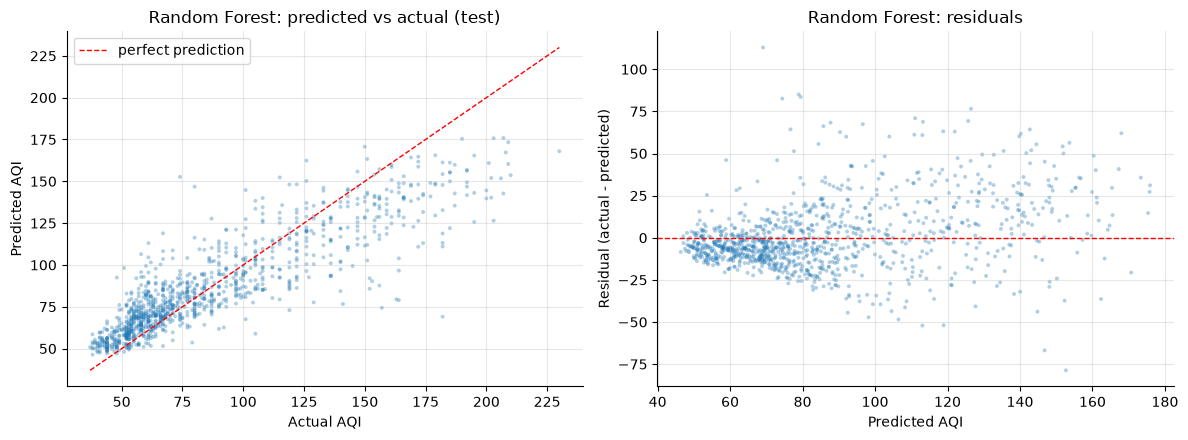

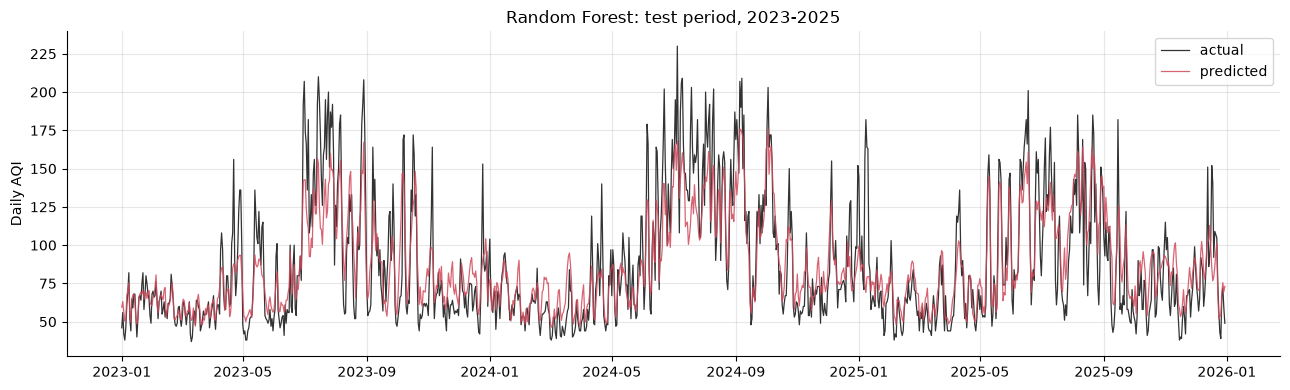

In [3]:
diagnostic_plots(MODEL_NAME, y_test, best.predict(X_test), meta['test_dates'])

## What the forest leaned on

Impurity-based importances are biased toward high-cardinality features, so this is
also checked with permutation importance on the **test** set — how much test RMSE
degrades when a single column is shuffled. That version answers the question we
actually care about: what is this model relying on to generalize?

Top 15 by impurity importance:
t2m_max                  12.70
t2m_mean                 12.30
t2m_max_roll3             7.59
t2m_max_lag1              7.21
t2m_mean_roll3            3.97
t2m_range                 3.61
t2m_min                   3.58
wind_speed_mean           3.37
doy_cos                   3.30
t2m_mean_lag1             3.14
wind_speed_mean_roll3     3.00
t2m_max_lag2              2.75
doy_sin                   2.25
calm_hours                2.23
v10m_mean                 1.96



Top 15 by permutation importance on test (AQI RMSE points lost when shuffled):
t2m_max                  3.919
t2m_mean                 3.368
t2m_max_roll3            1.852
t2m_max_lag1             1.420
doy_cos                  1.403
t2m_range                1.221
wind_speed_mean          0.760
wind_speed_mean_roll3    0.630
doy_sin                  0.582
calm_hours               0.400
t2m_mean_roll3           0.393
t2m_min                  0.374
v10m_mean                0.299
t2m_mean_lag1            0.282
wind_speed_max           0.278


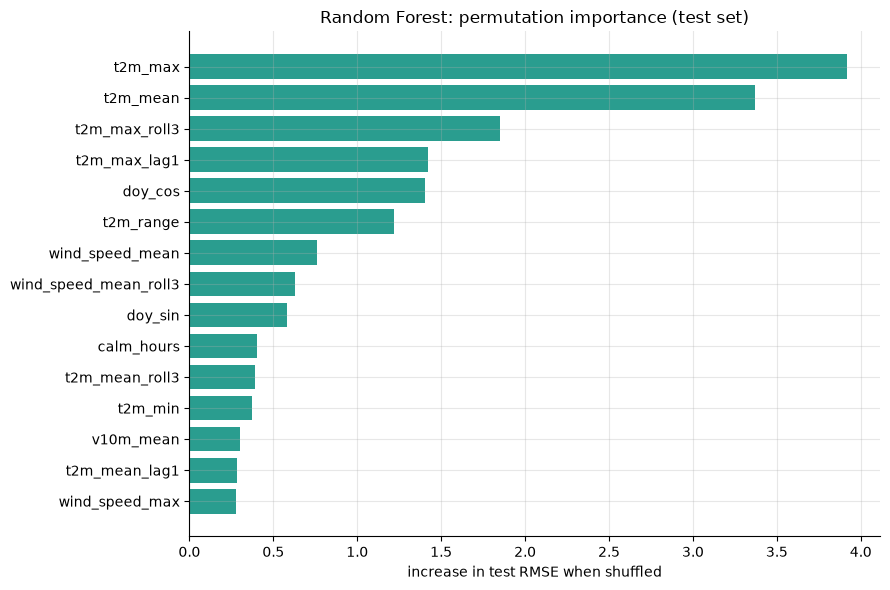

In [4]:
from sklearn.inspection import permutation_importance

imp = pd.Series(best.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('Top 15 by impurity importance:')
print((imp.head(15) * 100).round(2).to_string())

perm = permutation_importance(best, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1,
                              scoring='neg_root_mean_squared_error')
perm_s = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)
print('\nTop 15 by permutation importance on test (AQI RMSE points lost when shuffled):')
print(perm_s.head(15).round(3).to_string())

with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(9, 6))
    sel = perm_s.head(15)[::-1]
    ax.barh(sel.index, sel.values, color='#2a9d8f')
    ax.set_xlabel('increase in test RMSE when shuffled')
    ax.set_title('Random Forest: permutation importance (test set)')
    plt.tight_layout(); plt.show()

## What this told us

**Test RMSE 20.3, R² 0.748** — a 3.7-point RMSE improvement on linear regression,
confirming there is nonlinear structure that OLS cannot reach.

The overfit gap is large: train RMSE 8.8 versus test 20.3. With
`min_samples_leaf=1` the trees are allowed to isolate individual training days, so
the forest partly memorizes 2016–2022. Worth noting that CV *chose* this — the
tuning tried leaf sizes of 2 and 4 and preferred 1, meaning the memorization is not
costing it generalization here, just making the training score meaningless.

The two importance measures disagree in an instructive way. Impurity importance
spreads credit across the whole correlated temperature block (`t2m_max` 12.7%,
`t2m_mean` 12.3%, `t2m_max_roll3` 7.6%). Permutation importance on the test set
concentrates it: `t2m_max` costs 3.9 RMSE points when shuffled, `t2m_mean` 3.4, and
everything else drops below 2. Shuffling one temperature column barely hurts when
its correlated twins survive to fill in — which is exactly why permutation
importance should be read as "what is *uniquely* carried by this feature."

`doy_cos` at 1.40 is the interesting non-temperature entry: **day of year matters
beyond what temperature already captures**, so there is a seasonal driver — sun
angle, marine layer behaviour, seasonal emissions — the weather variables miss.